# 模様研究の準備：反応と拡散を分けて観察する

対応章：[20_pattern_foundations.md](../chapters/20_pattern_foundations.md)

反応拡散方程式へ進む前に，反応だけの更新と拡散だけの更新を同じ初期状態から計算する．反応は各格子点の値だけを使い，拡散は上下左右の値を使うことをコードと図で確認する．

## ライブラリと初期状態

中央が高い2次元の場を用意する．格子間隔は1とし，端は反対側へつながる周期境界として扱う．

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n = 51
coordinate = np.arange(n) - n // 2
X, Y = np.meshgrid(coordinate, coordinate)
u0 = 0.15 + 0.65 * np.exp(-(X**2 + Y**2) / (2 * 5.0**2))

print(f'initial range = [{u0.min():.3f}, {u0.max():.3f}]')
print(f'initial variance = {u0.var():.5f}')

initial range = [0.150, 0.800]
initial variance = 0.01122


## 反応と拡散の更新

反応にはロジスティック型の $u(1-u)$ を使う．これは模様の完成モデルではなく，各点で独立に値が変わる例である．拡散には5点差分を使う．np.rollは周期境界を越えた隣接点を取得している．

In [2]:
def laplacian_periodic(u):
    return (
        np.roll(u, 1, axis=0)
        + np.roll(u, -1, axis=0)
        + np.roll(u, 1, axis=1)
        + np.roll(u, -1, axis=1)
        - 4.0 * u
    )


def evolve(u_initial, reaction_rate=0.0, diffusion=0.0, dt=0.1, steps=80):
    u = u_initial.copy()
    for _ in range(steps):
        reaction = reaction_rate * u * (1.0 - u)
        spatial_spreading = diffusion * laplacian_periodic(u)
        u = u + dt * (reaction + spatial_spreading)
    return u


u_reaction = evolve(u0, reaction_rate=0.4, diffusion=0.0)
u_diffusion = evolve(u0, reaction_rate=0.0, diffusion=0.20)

## 図で比較する

3枚とも同じ色範囲を使う．色だけで判断せず，最小値，最大値，空間分散も確認する．拡散だけの場合は総量をほぼ保ちながら空間分散が小さくなる．

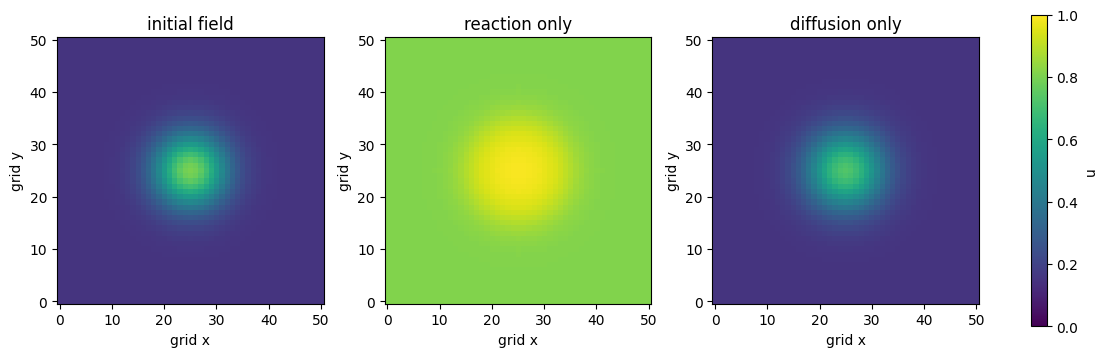

initial field : min=0.150, max=0.800, mean=0.189, variance=0.01122
reaction only : min=0.812, max=0.990, mean=0.833, variance=0.00189
diffusion only: min=0.150, max=0.727, mean=0.189, variance=0.00977


In [3]:
fields = [u0, u_reaction, u_diffusion]
titles = ['initial field', 'reaction only', 'diffusion only']

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), constrained_layout=True)
for ax, field, title in zip(axes, fields, titles):
    image = ax.imshow(field, origin='lower', vmin=0.0, vmax=1.0, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('grid x')
    ax.set_ylabel('grid y')
fig.colorbar(image, ax=axes, label='u')
plt.show()

for title, field in zip(titles, fields):
    print(
        f'{title:14s}: min={field.min():.3f}, max={field.max():.3f}, '
        f'mean={field.mean():.3f}, variance={field.var():.5f}'
    )

## 課題

1. reaction_rateとdiffusionの両方を0にし，初期状態が変わらないことを確認する．
2. diffusionを0.10，0.20，0.40と変え，空間分散がどのように変化するか表にする．
3. reaction_rateとdiffusionの両方を正にし，反応だけ，拡散だけの場合と比較する．各項の効果が図のどこに現れたか説明する．
4. 初期状態を一様な配列へ変える．拡散だけでは値が変化しない理由を5点ラプラシアンから説明する．